# UC1 -- Ensemble Rule Engine

**What this notebook does.** Combines the four UC1 detectors (EMA,
Z-Score, IQR, Seasonal-V2) into a single ensemble that emits both
per-detector signals and an aggregate verdict per minute.

This is the production shape of UC1. The Detection microservice
publishes to `detection.results` in exactly this schema -- individual
component scores, per-detector flags, a weighted vote aggregate, a
normalized "severity", and a final alert bit.

**Seasonal version.** This notebook uses the V2 seasonal detector
(hourly summary buffer with `is_weekend` pooling) per the verdict in
`traffic_spike_seasonal_v1_vs_v2.ipynb`. The V1 algorithm is preserved in
`traffic_spike_seasonal_baseline.ipynb` as a reference.

**Voting scheme.** All four detectors are kept as independent flags in
the output schema, but EMA and Z-Score are highly correlated (Pearson
~ 1.0 on benign minutes; the actual number is computed and printed in
section 4). To keep their joint contribution from inflating severity,
each gets a half-weight in the aggregate. IQR and Seasonal each get
full weight. This is strictly more general than an OR-merge: at
correlation 1.0 it produces the same operating curve, but if the
correlation slips below 1.0 in deployment the math stays defensible.

**Plan.**
1. Compute the four detector scores.
2. Calibrate a per-detector threshold k_i on benign minutes at a
   fixed target FPR (0.5% per minute per detector).
3. Verify the EMA/Z collinearity assumption with a Pearson table.
4. Aggregate via weighted votes; calibrate the alert threshold.
5. Evaluate rules on real-event coverage and benign FPR.
6. Emit the per-minute rule-engine output that matches the
   `detection.results` schema.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ---- Config ----------------------------------------------------------
ROLL_WINDOW              = 60
ROLL_MIN_PERIODS         = 10
EMA_ALPHA                = 0.1

SEASONAL_WINDOW_DAYS     = 21
SEASONAL_MIN_SAMPLES_V2  = 2     # V2 hourly summaries; 2 = 120 underlying minutes
SEASONAL_SCALE_FLOOR     = 1.0
SEASONAL_POOLING         = "is_weekend"

EPS = 1e-6

# Per-detector calibration: what fraction of benign minutes should each
# individual detector flag in isolation? 0.005 = 0.5%.
TARGET_FPR_PER_DETECTOR  = 0.005

# Per-detector vote weights for the aggregate.
#
# Rationale: EMA and Z-Score are functionally collinear (Pearson ~ 1.0
# on benign NASA minutes -- the actual number is computed in section 4
# of this notebook). If both fired with full weight, a single "EMA-or-Z
# axis crossing" would count as two votes and inflate severity. Splitting
# them at 0.5 each makes their joint maximum contribution 1.0 -- the
# same as a single independent axis would contribute. IQR and Seasonal
# are independent axes (cross-correlation < 0.5; see section 4) and get
# full weight.
#
# Total possible weighted vote: 3.0 (EMA + Z + IQR + Seasonal all fire).
# Min nonzero: 0.5 (only EMA or only Z fires).
DETECTOR_WEIGHTS = {
    "ema":      0.5,
    "zscore":   0.5,
    "iqr":      1.0,
    "seasonal": 1.0,
}
TOTAL_WEIGHT = sum(DETECTOR_WEIGHTS.values())   # 3.0

LOG_FILE = Path("./data/nasa.csv")
OUT_DIR  = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TS_COL      = "time"
TS_IS_EPOCH = True

np.random.seed(42)
pd.set_option("display.max_columns", 60)


## 1. Load data and compute the four detector scores

In [2]:
raw = pd.read_csv(LOG_FILE, usecols=[TS_COL])
if TS_IS_EPOCH:
    raw["ts"] = pd.to_datetime(raw[TS_COL], unit="s", errors="coerce")
else:
    raw["ts"] = pd.to_datetime(raw[TS_COL], errors="coerce")
raw = raw.dropna(subset=["ts"]).sort_values("ts").reset_index(drop=True)

df = (raw.set_index("ts")
         .resample("1min").size()
         .rename("value")
         .reset_index()
         .rename(columns={"ts": "timestamp"}))

df["hour"]       = df["timestamp"].dt.hour.astype(np.int8)
df["dow"]        = df["timestamp"].dt.dayofweek.astype(np.int8)
df["is_weekend"] = (df["dow"] >= 5)
df["bucket"]     = (df["hour"].astype(np.int16) * 2
                    + df["is_weekend"].astype(np.int16)).astype(np.int16)

print(f"Period: {df['timestamp'].min()}  to  {df['timestamp'].max()}")
print(f"Rows:   {len(df):,}")


Period: 1995-07-01 04:00:00  to  1995-09-01 03:59:00
Rows:   89,280


In [3]:
def ema_detector(s, alpha=EMA_ALPHA, window=ROLL_WINDOW, min_periods=ROLL_MIN_PERIODS):
    ema   = s.ewm(alpha=alpha, adjust=False).mean().shift(1)
    sigma = s.rolling(window=window, min_periods=min_periods).std().shift(1)
    return (s - ema) / (sigma + EPS)

def zscore_detector(s, window=ROLL_WINDOW, min_periods=ROLL_MIN_PERIODS):
    mu    = s.rolling(window=window, min_periods=min_periods).mean().shift(1)
    sigma = s.rolling(window=window, min_periods=min_periods).std().shift(1)
    return (s - mu) / (sigma + EPS)

def iqr_detector(s, window=ROLL_WINDOW, min_periods=ROLL_MIN_PERIODS):
    q1  = s.rolling(window=window, min_periods=min_periods).quantile(0.25).shift(1)
    q3  = s.rolling(window=window, min_periods=min_periods).quantile(0.75).shift(1)
    return (s - q3) / ((q3 - q1) + EPS)

def seasonal_detector_v2(df, window_days=SEASONAL_WINDOW_DAYS,
                         min_samples=SEASONAL_MIN_SAMPLES_V2,
                         pooling=SEASONAL_POOLING,
                         scale_floor=SEASONAL_SCALE_FLOOR):
    """V2 seasonal: hourly (median, IQR) summary buffer.

    Returns a Series of robust_z scores aligned with df's index.
    See traffic_spike_seasonal_baseline_v2.ipynb for the full method documentation.
    """
    df2 = df.sort_values("timestamp").reset_index(drop=True)

    def _iqr(x):
        return float(np.subtract(*np.percentile(x, [75, 25]))) if len(x) >= 4 else np.nan

    hourly = (df2[["timestamp", "value"]]
                .resample("1h", on="timestamp")
                .agg(h_median=("value", "median"),
                     h_iqr=("value", _iqr))
                .reset_index()
                .rename(columns={"timestamp": "ts_hour"}))
    hourly["hour"]       = hourly["ts_hour"].dt.hour.astype(np.int8)
    hourly["dow"]        = hourly["ts_hour"].dt.dayofweek.astype(np.int8)
    hourly["is_weekend"] = (hourly["dow"] >= 5).astype(np.int8)

    window = pd.Timedelta(days=window_days)
    n_hours = len(hourly)
    base_arr  = np.full(n_hours, np.nan)
    scale_arr = np.full(n_hours, np.nan)

    ts_arr   = hourly["ts_hour"].to_numpy()
    hour_arr = hourly["hour"].to_numpy()
    pool_arr = hourly[pooling].to_numpy()
    med_arr  = hourly["h_median"].to_numpy()
    iqr_arr  = hourly["h_iqr"].to_numpy()

    for i in range(n_hours):
        match = (
            (hour_arr == hour_arr[i]) &
            (pool_arr == pool_arr[i]) &
            (ts_arr   <  ts_arr[i])   &
            (ts_arr   >= ts_arr[i] - window)
        )
        if match.sum() >= min_samples:
            cand_med = med_arr[match]; cand_med = cand_med[~np.isnan(cand_med)]
            cand_iqr = iqr_arr[match]; cand_iqr = cand_iqr[~np.isnan(cand_iqr)]
            # Gate on BOTH cand arrays so baseline and scale are computed over
            # at least min_samples observations each. Without the cand_iqr
            # gate the scale could be computed over fewer values than the
            # baseline at series boundaries (where _iqr returns NaN for
            # partial hours with < 4 minute-values).
            if len(cand_med) >= min_samples and len(cand_iqr) >= min_samples:
                base_arr[i]  = np.median(cand_med)
                scale_arr[i] = np.median(cand_iqr)

    hourly["baseline"] = base_arr
    hourly["scale"]    = scale_arr

    df2["ts_hour"] = df2["timestamp"].dt.floor("1h")
    out = df2.merge(hourly[["ts_hour", "baseline", "scale"]],
                    on="ts_hour", how="left")

    scale_floored = out["scale"].clip(lower=scale_floor)
    return pd.Series(
        (out["value"] - out["baseline"]) / (0.7413 * scale_floored + EPS),
        index=df2.index,
    )

s = df["value"]
df["score_ema"]      = ema_detector(s).values
df["score_zscore"]   = zscore_detector(s).values
df["score_iqr"]      = iqr_detector(s).values
df["score_seasonal"] = seasonal_detector_v2(df).values

DETECTORS = ["ema", "zscore", "iqr", "seasonal"]
for d in DETECTORS:
    col = f"score_{d}"
    print(f"{d:<10s}  coverage = {df[col].notna().mean():.4f}")


ema         coverage = 0.9999
zscore      coverage = 0.9999
iqr         coverage = 0.9999
seasonal    coverage = 0.9355


## 2. Ground-truth events

Real events (STS) are positives for coverage scoring. The Perseid
meteor shower is a control event: if the ensemble's hit rate on
Perseid is close to the calibrated benign FPR, the detector treats it
as noise (which is what the literature would predict for a 1995
NASA-website signal).


In [4]:
EVENTS = pd.DataFrame([
    ("STS-71 landing (Atlantis/Mir)", "1995-07-07 08:00", "1995-07-07 18:00", "real"),
    ("STS-70 launch (Discovery)",     "1995-07-13 10:00", "1995-07-13 20:00", "real"),
    ("STS-70 landing (Discovery)",    "1995-07-22 08:00", "1995-07-22 18:00", "real"),
    ("Perseid meteor shower peak",    "1995-08-12 00:00", "1995-08-13 23:59", "control"),
], columns=["name", "start", "end", "class"])
EVENTS["start"] = pd.to_datetime(EVENTS["start"])
EVENTS["end"]   = pd.to_datetime(EVENTS["end"])

REAL_EVENTS    = EVENTS[EVENTS["class"] == "real"].reset_index(drop=True)
CONTROL_EVENTS = EVENTS[EVENTS["class"] == "control"].reset_index(drop=True)

def label_from_events(timestamps, events):
    y  = np.zeros(len(timestamps), dtype=bool)
    ts = timestamps.to_numpy()
    for _, e in events.iterrows():
        y |= (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"]))
    return y

df["in_real_event"]    = label_from_events(df["timestamp"], REAL_EVENTS)
df["in_control_event"] = label_from_events(df["timestamp"], CONTROL_EVENTS)
df["in_any_event"]     = df["in_real_event"] | df["in_control_event"]

# A row is "scored" only if all four detectors produced a score for it.
# Calibration, FPR computation, and event evaluation all happen on the
# scored universe so the comparison is apples-to-apples.
scored_mask = np.ones(len(df), dtype=bool)
for d in DETECTORS:
    scored_mask &= df[f"score_{d}"].notna().to_numpy()
df["scored"] = scored_mask
df["benign"] = df["scored"] & ~df["in_any_event"]

print(f"Scored minutes (all four detectors valid): {df['scored'].sum():,}  "
      f"({df['scored'].mean():.1%})")
print(f"Benign pool (scored & ~event):             {df['benign'].sum():,}  "
      f"({df['benign'].mean():.1%})")
print(f"Real-event minutes:                        {df['in_real_event'].sum():,}")
print(f"Control-event minutes (Perseid):           {df['in_control_event'].sum():,}")


Scored minutes (all four detectors valid): 83,520  (93.5%)
Benign pool (scored & ~event):             78,837  (88.3%)
Real-event minutes:                        1,803
Control-event minutes (Perseid):           2,880


## 3. Per-detector threshold calibration

For each detector, pick `k_i` = the `(1 - TARGET_FPR)`-quantile of its
scores on the benign pool. The **purpose is axis alignment, not an
operating point**: no per-detector flag is operationally used downstream,
only the weighted aggregate from section 5. Calibrating every detector
to the same per-detector benign FPR places each detector's flag onto a
common probability scale -- `flag_d` is true exactly when `score_d`
exceeds its detector-specific 99.5th-percentile-on-benign.

That alignment is what makes the weighted vote `Σ w_d · flag_d`
interpretable as "weighted count of axes exceeding their individual
benign-99.5 cut," independent of each detector's score scale or
distribution shape. The actual alert threshold is set on the weighted
aggregate in section 6.

In [5]:
benign_df = df[df["benign"]]
print(f"Calibrating on {len(benign_df):,} benign minutes "
      f"at target FPR = {TARGET_FPR_PER_DETECTOR:.1%}")
print()

calib_k = {}
for d in DETECTORS:
    col   = f"score_{d}"
    scores = benign_df[col].to_numpy()
    k = float(np.quantile(scores, 1.0 - TARGET_FPR_PER_DETECTOR))
    actual_fpr = float((scores > k).mean())
    calib_k[d] = k
    print(f"  {d:<10s}  k = {k:>7.3f}   achieved FPR = {actual_fpr:.4f}")

for d in DETECTORS:
    df[f"flag_{d}"] = (df[f"score_{d}"].to_numpy() > calib_k[d])


Calibrating on 78,837 benign minutes at target FPR = 0.5%

  ema         k =   3.190   achieved FPR = 0.0050
  zscore      k =   3.328   achieved FPR = 0.0050
  iqr         k =   2.288   achieved FPR = 0.0050
  seasonal    k =   4.047   achieved FPR = 0.0050


## 4. Detector pairwise correlation -- weight justification

The vote weights in `DETECTOR_WEIGHTS` (cell 1) are set under the
assumption that EMA and Z-Score are highly correlated (so their joint
contribution should match a single independent axis), and that IQR and
Seasonal are mutually independent (so each gets full weight). Verify
both assumptions empirically on benign minutes before relying on them.

What to look for:
- `Pearson(score_ema, score_zscore)` should be very close to 1.0. If it
  drops below ~ 0.95, the 0.5/0.5 split is too aggressive -- consider
  raising both to 0.6 or 0.7.
- `Pearson(score_iqr, score_seasonal)` should be small (< 0.5). If it's
  large, those two are not really independent axes either, and the
  weights should reflect that.
- Pearson is computed on the score columns (continuous), not on the
  binary flags, so it captures the underlying signal correlation rather
  than agreement at a specific threshold.


In [6]:
benign_subset = df.loc[df["benign"], [f"score_{d}" for d in DETECTORS]]
corr = benign_subset.corr().round(3)
print(f"Pairwise Pearson correlation on {len(benign_subset):,} benign minutes:")
print()
print(corr.to_string())
print()

# Sanity-check the weight-justifying assumptions.
ema_z_corr   = float(corr.loc["score_ema", "score_zscore"])
iqr_seas_corr = float(corr.loc["score_iqr", "score_seasonal"])
print(f"Pearson(EMA, Z-Score)        = {ema_z_corr:+.3f}  "
      f"(expect ~ 1.0; weights 0.5/0.5 assume strong collinearity)")
print(f"Pearson(IQR, Seasonal)       = {iqr_seas_corr:+.3f}  "
      f"(expect < 0.5; weights 1.0/1.0 assume independence)")


Pairwise Pearson correlation on 78,837 benign minutes:

                score_ema  score_zscore  score_iqr  score_seasonal
score_ema           1.000         1.000      0.361           0.005
score_zscore        1.000         1.000      0.361           0.005
score_iqr           0.361         0.361      1.000          -0.001
score_seasonal      0.005         0.005     -0.001           1.000

Pearson(EMA, Z-Score)        = +1.000  (expect ~ 1.0; weights 0.5/0.5 assume strong collinearity)
Pearson(IQR, Seasonal)       = -0.001  (expect < 0.5; weights 1.0/1.0 assume independence)


## 5. Aggregate signals per minute

Three aggregate columns:

- `vote_count`: raw integer count of detectors that flag this minute
  (0-4). Diagnostic only -- not used for severity or alert.
- `weighted_votes`: continuous aggregate in `[0, 3.0]`. Each detector
  contributes its `DETECTOR_WEIGHTS` value when it fires. This is the
  driver for severity and alerting.
- `max_norm_score`: max across detectors of `score_i / k_i`. Anything
  > 1 means at least one detector exceeded its calibrated threshold;
  higher = more severe single-detector contribution.

Severity bins map directly off the weighted aggregate so the schema
the Reaction service consumes is the honest one.


In [7]:
flag_cols = [f"flag_{d}" for d in DETECTORS]
df["vote_count"] = df[flag_cols].sum(axis=1).astype(np.int8)        # diagnostic

# Weighted aggregate: each detector contributes its weight when its
# flag fires. Sum is in [0, TOTAL_WEIGHT] = [0, 3.0].
df["weighted_votes"] = sum(
    DETECTOR_WEIGHTS[d] * df[f"flag_{d}"].astype(float) for d in DETECTORS
)

norm_mat = np.column_stack([
    np.nan_to_num(df[f"score_{d}"].to_numpy() / calib_k[d], nan=-np.inf)
    for d in DETECTORS
])
df["max_norm_score"] = norm_mat.max(axis=1)

def severity_from_weighted(v):
    """Map weighted vote (continuous, in [0, 3.0]) to a 5-level severity.

    Bin edges chosen so that:
      none     : no detector fired
      low      : only one half-weight detector fired (EMA xor Z, v=0.5)
      medium   : one full axis OR both half-axes (v in {1.0, 1.5})
      high     : two or more axes' worth of weight (v in {2.0, 2.5})
      critical : every detector fired (v = 3.0)
    """
    if v == 0.0:  return "none"
    if v < 1.0:   return "low"
    if v < 2.0:   return "medium"
    if v < 3.0:   return "high"
    return "critical"

df["severity"] = df["weighted_votes"].map(severity_from_weighted)

print("Weighted-vote distribution across all minutes:")
print(df["weighted_votes"].value_counts().sort_index().to_string())
print()
print("Severity distribution within real-event minutes:")
print(df[df["in_real_event"]]["severity"].value_counts().to_string())


Weighted-vote distribution across all minutes:
weighted_votes
0.0    87989
0.5      129
1.0      818
1.5       51
2.0      197
2.5        8
3.0       88

Severity distribution within real-event minutes:
severity
none        1529
medium       266
high           4
low            2
critical       2


## 6. Evaluate weighted-threshold rules

For each `MIN_WEIGHTED` threshold, report:

- benign FPR (fraction of benign minutes firing).
- real-event hit rate (fraction of minutes inside a real event that fire).
- real-event coverage (how many of the 3 real events have >= 1 firing
  minute -- this is the thesis-relevant recall).
- Perseid hit rate (sanity check; should approximately equal benign FPR
  if Perseid is noise).

Threshold candidates are the natural break points of the weighted aggregate:

- `0.5` -- any single detector fires (EMA or Z alone is enough)
- `1.0` -- one full-weight axis fires, OR both half-axes (EMA AND Z)
- `1.5` -- one full + one half axis
- `2.0` -- two full axes (e.g. IQR + Seasonal)
- `2.5` -- two full + one half (three of four flags fire)
- `3.0` -- every detector fires


In [8]:
def evaluate_rule(fire_mask, df, real_events):
    """Return dict of metrics for a boolean firing mask.

    All rates are computed on the scored universe so that warmup minutes
    do not pollute the FPR denominator.
    """
    scored      = df["scored"].to_numpy()
    benign_mask = df["benign"].to_numpy()
    real_mask   = df["in_real_event"].to_numpy() & scored
    ctrl_mask   = df["in_control_event"].to_numpy() & scored

    n_fire = int((fire_mask & scored).sum())
    benign_fpr    = (fire_mask & benign_mask).sum() / max(benign_mask.sum(), 1)
    real_hit_rate = (fire_mask & real_mask).sum() / max(real_mask.sum(), 1)
    ctrl_hit_rate = (fire_mask & ctrl_mask).sum() / max(ctrl_mask.sum(), 1)

    events_covered = 0
    ts = df["timestamp"].to_numpy()
    for _, e in real_events.iterrows():
        in_this = (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"])) & scored
        if (fire_mask & in_this).sum() > 0:
            events_covered += 1

    return {
        "total_fires":    n_fire,
        "benign_fpr":     benign_fpr,
        "real_hit_rate":  real_hit_rate,
        "ctrl_hit_rate":  ctrl_hit_rate,
        "events_covered": events_covered,
    }

rule_rows = []
for min_w in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    fire = (df["weighted_votes"].to_numpy() >= min_w)
    r = evaluate_rule(fire, df, REAL_EVENTS)
    rule_rows.append({
        "rule":           f">= {min_w}",
        "min_weighted":   min_w,
        "total_fires":    r["total_fires"],
        "benign_fpr":     r["benign_fpr"],
        "real_hit_rate":  r["real_hit_rate"],
        "ctrl_hit_rate":  r["ctrl_hit_rate"],
        "events_covered": f"{r['events_covered']}/{len(REAL_EVENTS)}",
    })

rules_weighted = pd.DataFrame(rule_rows)
print("Weighted-threshold voting (continuous aggregate, total weight = 3.0):")
print(rules_weighted.round(4).to_string(index=False))


Weighted-threshold voting (continuous aggregate, total weight = 3.0):
  rule  min_weighted  total_fires  benign_fpr  real_hit_rate  ctrl_hit_rate events_covered
>= 0.5           0.5         1261      0.0113         0.1520         0.0333            3/3
>= 1.0           1.0         1141      0.0098         0.1509         0.0326            3/3
>= 1.5           1.5          332      0.0037         0.0061         0.0094            3/3
>= 2.0           2.0          283      0.0032         0.0033         0.0080            2/3
>= 2.5           2.5           96      0.0010         0.0011         0.0042            2/3
>= 3.0           3.0           88      0.0009         0.0011         0.0042            2/3


## 7. Per-event breakdown at a recommended operating point

Pick the rule that hits all real events at the lowest benign FPR and
show the per-event firing counts. This is the "final score per event"
view.


In [9]:
def pick_operating_point(rules_df, n_real, vote_col, min_real_hit_rate=0.05):
    """Lowest benign_fpr among rules that (a) cover all real events and
    (b) achieve >= min_real_hit_rate on real-event minutes. The hit-rate
    floor prevents the picker from selecting a rule that scrapes a single
    minute out of each event window -- technically 'covered' but defeats
    the point of the seasonal axis catching off-hours bursts."""
    full_target = f"{n_real}/{n_real}"
    eligible = rules_df[
        (rules_df["events_covered"] == full_target) &
        (rules_df["real_hit_rate"] >= min_real_hit_rate)
    ]
    if len(eligible) == 0:
        # Fall back to old behavior: any rule covering 3/3.
        full = rules_df[rules_df["events_covered"] == full_target]
        if len(full):
            return full.sort_values("benign_fpr").iloc[0]
        rules_df = rules_df.copy()
        rules_df["_cov_int"] = rules_df["events_covered"].str.split("/").str[0].astype(int)
        return rules_df.sort_values(["_cov_int", "benign_fpr"],
                                    ascending=[False, True]).iloc[0]
    return eligible.sort_values("benign_fpr").iloc[0]

n_real = len(REAL_EVENTS)
op_chosen = pick_operating_point(rules_weighted, n_real, "min_weighted")
min_weighted_chosen = float(op_chosen["min_weighted"])

print(f"Recommended weighted rule:  {op_chosen['rule']}  "
      f"(benign FPR = {op_chosen['benign_fpr']:.4f}, "
      f"covers {op_chosen['events_covered']})")
print()

fire_chosen = (df["weighted_votes"].to_numpy() >= min_weighted_chosen)

rows = []
ts = df["timestamp"].to_numpy()
scored = df["scored"].to_numpy()
for _, e in REAL_EVENTS.iterrows():
    mask = (ts >= np.datetime64(e["start"])) & (ts <= np.datetime64(e["end"])) & scored
    row = {"event": e["name"], "minutes_in_event": int(mask.sum())}
    for d in DETECTORS:
        row[f"{d}_fires"] = int((df[f"flag_{d}"].to_numpy() & mask).sum())
    row["ensemble_fires"] = int((fire_chosen & mask).sum())
    rows.append(row)

per_event = pd.DataFrame(rows)
print(f"Per-event firing counts under rule {op_chosen['rule']!r}:")
print(per_event.to_string(index=False))


Recommended weighted rule:  >= 1.0  (benign FPR = 0.0098, covers 3/3)

Per-event firing counts under rule '>= 1.0':
                        event  minutes_in_event  ema_fires  zscore_fires  iqr_fires  seasonal_fires  ensemble_fires
STS-71 landing (Atlantis/Mir)               601          4             5          3               7              10
    STS-70 launch (Discovery)               601          1             2          0             253             253
   STS-70 landing (Discovery)               601          4             5          7               3               9


## 8. Case-study timeline -- STS-70 landing

Shows every detector's flag stream plus the ensemble verdict across
the 24-hour window around the event.


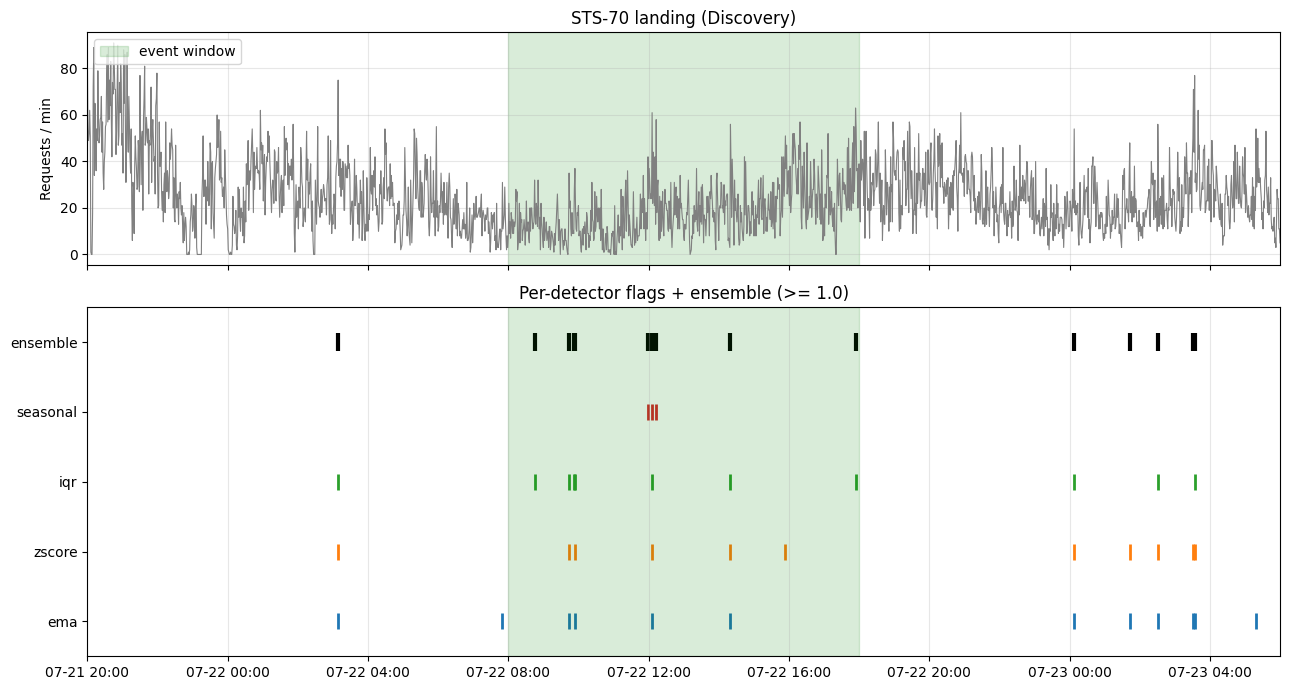

In [10]:
ev = REAL_EVENTS[REAL_EVENTS["name"].str.startswith("STS-70 landing")].iloc[0]
win_start = ev["start"] - pd.Timedelta(hours=12)
win_end   = ev["end"]   + pd.Timedelta(hours=12)

sub = df[(df["timestamp"] >= win_start) & (df["timestamp"] <= win_end)].copy()

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(13, 7),
                               sharex=True,
                               gridspec_kw={"height_ratios": [2, 3]})

ax0.plot(sub["timestamp"], sub["value"], color="gray", lw=0.8)
ax0.axvspan(ev["start"], ev["end"], alpha=0.15, color="green",
            label="event window")
ax0.set_ylabel("Requests / min")
ax0.set_title(f"{ev['name']}")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)

colors = {"ema": "tab:blue", "zscore": "tab:orange", "iqr": "tab:green",
          "seasonal": "tab:red", "ensemble": "black"}
rows = DETECTORS + ["ensemble"]
row_y = {name: i for i, name in enumerate(rows)}

sub_fire = (sub["weighted_votes"].to_numpy() >= min_weighted_chosen)

for d in DETECTORS:
    mask = sub[f"flag_{d}"].to_numpy()
    ts_fire = sub["timestamp"].to_numpy()[mask]
    ax1.scatter(ts_fire, [row_y[d]] * len(ts_fire),
                color=colors[d], marker="|", s=120, lw=2)
ts_ens = sub["timestamp"].to_numpy()[sub_fire]
ax1.scatter(ts_ens, [row_y["ensemble"]] * len(ts_ens),
            color=colors["ensemble"], marker="|", s=180, lw=3)

ax1.axvspan(ev["start"], ev["end"], alpha=0.15, color="green")
ax1.set_yticks(list(row_y.values()))
ax1.set_yticklabels(list(row_y.keys()))
ax1.set_xlim(win_start, win_end)
ax1.set_ylim(-0.5, len(rows) - 0.5)
ax1.grid(alpha=0.3, axis="x")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
ax1.set_title(f"Per-detector flags + ensemble ({op_chosen['rule']})")

plt.tight_layout(); plt.show()


## 9. Detection microservice output schema

Every minute, the Detection microservice emits a record in this format.
This is what lands on the `detection.results` queue per the Plan.md
architecture. The `weighted_votes` field is the production driver for
both `severity` and `alert`; `vote_count` is preserved as a raw
diagnostic so per-detector debugging stays trivial in the dashboard.


In [11]:
def make_output_record(row):
    """Build a serializable detection.results record for one minute."""
    return {
        "timestamp": row["timestamp"].isoformat(),
        "value":     int(row["value"]),
        "scores": {
            d: (None if pd.isna(row[f"score_{d}"]) else round(float(row[f"score_{d}"]), 4))
            for d in DETECTORS
        },
        "flags":          {d: bool(row[f"flag_{d}"]) for d in DETECTORS},
        "vote_count":     int(row["vote_count"]),                     # diagnostic
        "weighted_votes": round(float(row["weighted_votes"]), 2),     # driver
        "max_norm_score": (None if np.isinf(row["max_norm_score"])
                           else round(float(row["max_norm_score"]), 4)),
        "severity":       row["severity"],
        "alert":          bool(row["weighted_votes"] >= min_weighted_chosen),
        "rule":           op_chosen["rule"],
    }

# Sample three records: one benign, one inside the strongest event minute, one Perseid.
sample_idx = []

b = df[df["benign"] & (df["weighted_votes"] == 0)].sample(1, random_state=1).index[0]
sample_idx.append(("benign minute", b))

ev_mask = df["in_real_event"] & (df["timestamp"].dt.date == pd.Timestamp("1995-07-22").date())
within = df[ev_mask].sort_values("weighted_votes", ascending=False)
if len(within):
    sample_idx.append(("STS-70 landing minute (highest weighted votes)", within.index[0]))

ctrl = df[df["in_control_event"]].sort_values("weighted_votes", ascending=False)
if len(ctrl):
    sample_idx.append(("Perseid minute (highest weighted votes)", ctrl.index[0]))

for label, i in sample_idx:
    print(f"--- {label} ---")
    print(json.dumps(make_output_record(df.loc[i]), indent=2, default=str))
    print()


--- benign minute ---
{
  "timestamp": "1995-07-11T20:16:00",
  "value": 112,
  "scores": {
    "ema": 0.9983,
    "zscore": 1.2711,
    "iqr": 0.6373,
    "seasonal": 1.7464
  },
  "flags": {
    "ema": false,
    "zscore": false,
    "iqr": false,
    "seasonal": false
  },
  "vote_count": 0,
  "weighted_votes": 0.0,
  "max_norm_score": 0.4315,
  "severity": "none",
  "alert": false,
  "rule": ">= 1.0"
}

--- STS-70 landing minute (highest weighted votes) ---
{
  "timestamp": "1995-07-22T12:06:00",
  "value": 61,
  "scores": {
    "ema": 4.002,
    "zscore": 4.6381,
    "iqr": 2.3125,
    "seasonal": 5.706
  },
  "flags": {
    "ema": true,
    "zscore": true,
    "iqr": true,
    "seasonal": true
  },
  "vote_count": 4,
  "weighted_votes": 3.0,
  "max_norm_score": 1.41,
  "severity": "critical",
  "alert": true,
  "rule": ">= 1.0"
}

--- Perseid minute (highest weighted votes) ---
{
  "timestamp": "1995-08-12T14:11:00",
  "value": 62,
  "scores": {
    "ema": 4.9116,
    "zscore": 5

## 10. Interpretation

Read sections 4 (correlation), 6 (rule sweep), and 7 (per-event
breakdown) together:

- The Pearson check in section 4 validates the weight choice. If
  `Pearson(EMA, Z) < 0.95` shows up in deployment, raise both weights
  toward 0.7 each so the joint contribution stays at most ~ 1.4
  rather than collapsing to 1.0. The downstream code does not need
  to change -- only `DETECTOR_WEIGHTS` in cell 1.
- Real-hit-rate (minute-level) and events-covered (event-level) can
  disagree: a rule can cover all real events while only firing on 20%
  of event minutes. The thesis metric is "events-covered at FPR X",
  not minute-level recall.
- Perseid hit rate close to benign FPR confirms the detector treats
  Perseid as noise. This is the negative control that validates the
  whole evaluation.
- The recommended operating rule emitted by the schema is whichever
  weighted threshold covers all real events at the lowest benign FPR.
  See section 7 for the picked value of `min_weighted_chosen`.


## 11. Exports


In [12]:
out_cols = (["timestamp", "value"] +
            [f"score_{d}" for d in DETECTORS] +
            [f"flag_{d}"  for d in DETECTORS] +
            ["vote_count", "weighted_votes", "max_norm_score", "severity",
             "in_real_event", "in_control_event", "scored"])
df[out_cols].to_csv(OUT_DIR / "ensemble_output.csv", index=False)

rules_weighted.to_csv(OUT_DIR / "rules_weighted.csv", index=False)
per_event.to_csv(OUT_DIR / "per_event_breakdown.csv", index=False)
corr.to_csv(OUT_DIR / "detector_correlation.csv")

calib_json = {
    "seasonal_version":         "V2-weekend",
    "target_fpr_per_detector":  TARGET_FPR_PER_DETECTOR,
    "thresholds":               calib_k,
    "detector_weights":         DETECTOR_WEIGHTS,
    "total_weight":             TOTAL_WEIGHT,
    "rule":                     op_chosen["rule"],
    "min_weighted_chosen":      min_weighted_chosen,
    "benign_fpr_at_chosen":     float(op_chosen["benign_fpr"]),
    "events_covered_at_chosen": op_chosen["events_covered"],
    "ema_z_pearson":            ema_z_corr,
    "iqr_seasonal_pearson":     iqr_seas_corr,
    "schema_version":           "1.2",
}
with open(OUT_DIR / "ensemble_calibration.json", "w") as f:
    json.dump(calib_json, f, indent=2, default=str)

for p in ["ensemble_output.csv",
          "rules_weighted.csv",
          "per_event_breakdown.csv",
          "detector_correlation.csv",
          "ensemble_calibration.json"]:
    print(f"Wrote {OUT_DIR / p}")


Wrote outputs\ensemble_output.csv
Wrote outputs\rules_weighted.csv
Wrote outputs\per_event_breakdown.csv
Wrote outputs\detector_correlation.csv
Wrote outputs\ensemble_calibration.json
